In [6]:
using Plots #Graficas
using LaTeXStrings #Mejora al momento de graficar
using SpecialFunctions #Uso de funciones Bessel de primer tipo 
using Measures #Uso para margenes y espacios 
using FFTW #uso para encontrar valores de k permitidos 
using BHFunctions

LoadError: ArgumentError: Package BHFunctions not found in current path.
- Run `import Pkg; Pkg.add("BHFunctions")` to install the BHFunctions package.

# Funciones a utilizar

In [2]:
######################################################################################
N = 2; #particulas
M = 20; #sitios  
#######################################################################################
v = generate_basis(N,M); 
D = length(v); #Dimensión de nuestra base

## Funcion de onda inicial y generacion de la representacion matricial del numero de ocupacion en nuestra cadena

In [22]:
ψ₀=initial_state(); 
Mocup = generate_matrices();

# Hamiltoniano $H(\theta , U, g, J)$

## Caminatas cuanticas

In [24]:
## Manera no eficiente pero util para determinar el tiempo final(tfin) 
t = 0:0.25:50  
###########PARAMETERS 
theta = 0.0
U_val = 0.0 
g_val = 0.0
###################### 
######################
#function quantum_walks(theta)
    ψ(t) = exp(-1im*H_theta(theta, U_val)*t)*ψ₀ 
    # Sea la matriz de resultados
    result = zeros(length(t), M)
    tfin = 0
    # Hacemos un perfil de densidad
@time    for (i, τ) in enumerate(t)
        ψ_vec = ψ(τ)                 # Sea ψ(τ)
        ψ_vec_conj = ψ_vec'           # ψ(τ) conjugado
        for p in 1:M
            result[i, p] = real(ψ_vec_conj * (Mocup[p] * ψ_vec))  # Valor esperado de la ocupación, se puede mejorar con producto interior
        end 
        if (result[i,M]>0.02) #Condición al tocar la frontera, obtenemos el tiempo en el cual la caminata cuantica toca la frontera.
            tfin = τ 
            break
        end 
    end 
    # Graficando la caminata cuantica con heatmap 
    result = result[1:length(0:0.25:tfin), :] #Una vez encontrado el tiempo donde toca el borde de la cadena 
    # nuestra caminata, solo nos quedamos con los datos hasta el tfin, debido a que al tomar los otros solo tendran valores 0 debido a que no 
    #fueron obtenidos
    # Definimos las etiquetas para nuestro tiempo en el heatmap
    Tperiod = tfin 
   # y_full_ticks = 0:0.25:Tperiod  # Rango de la cuadricula (0 a tfin con pasos de 0.25)
   #  y_labels = vec(range(1, Tperiod + 1))     # Las etiquetas que quiero mostrar especificamente
   #  y_label_indices = findall(x -> x in y_labels, y_full_ticks)  # Ponemos nuestras etiquetas sobre la cuadricula
   #  heatmap(result, color = cgrad([:white , :blue]), xlabel=L"\langle n_i \rangle", ylabel=L"t", yflip = true,  aspect_ratio=2, size=(400, 600), 
   #      yticks=(y_label_indices, y_labels), 
   #      xlimits=(0,M) , annotation=(8.5, 0.95, L"\theta = %$theta")) 

  0.415539 seconds (5.79 M allocations: 471.719 MiB, 4.31% gc time, 17.08% compilation time)


4.0

In [46]:
t = 0:0.25:tfin  
function quantum_walks(θ::Float64, Uva::Float64, gva::Float64)#, J::Float64=1.0)
    Ht = H_theta(θ::Float64, Uva, gva)
    H_spa = sparse(-1im*Ht)
    # Precompute the time evolution operator for each τ
    ψ_states = [expv(τ, H_spa, ψ₀; m=125) for τ in t]
    # Sea la matriz de resultados
    result = zeros(length(t), M)
     for (i, ψ_vec) in enumerate(ψ_states)
        for p in 1:M
            Mψ = Mocup[p] * ψ_vec  
            result[i, p] = real(dot(ψ_vec, Mψ))
        end
    end 
    # Grafica
    # Define y-axis ticks
    Tperiod = tfin
    y_full_ticks = 0:0.25:Tperiod  # Rango de la cuadricula (0 a tfin con pasos de 0.25)
    y_labels = vec(range(1, Tperiod + 1))     # Las etiquetas que quiero mostrar especificamente
    y_label_indices = findall(x -> x in y_labels, y_full_ticks)  # Indices
    heatmap(result, color = cgrad(:oslo, rev=true) #cgrad([:white , :blue])
        , xlabel=L"i", ylabel=L"t(\tau)", colorbar_title= "\n " * L"\langle \hat{n}_i \rangle",   yflip = true,  aspect_ratio=2, size=(600, 600), 
            yticks=(y_label_indices, y_labels), xlimits=(0,M) ,
            #title=L"Quantum~walk~for~U = %$Uva ~ \theta = %$θ ~g = %$gva",
            colorbar_tickfontsize = font(10),
            # fuentes
            guidefontsize = 25,    # Títulos de ejes (i, t) 
            colorbar_titlefontsize = 24, #Tamaño de la barra de calor
            tickfontsize = 19, top_margin = 11mm, right_margin = 11mm, 
        colorbar=true)#, legend_title =L"U = 0")  
            #titlefontsize = 15)     # Título
    annotate!(-1, -.75, text(L"\theta= \pi", 22, :black)) 
    annotate!(11, -.75, text(L"U= %$Uva", 22, :black)) 
    annotate!(23, -.75, text(L"g= %$gva", 22, :black))
end

quantum_walks (generic function with 1 method)

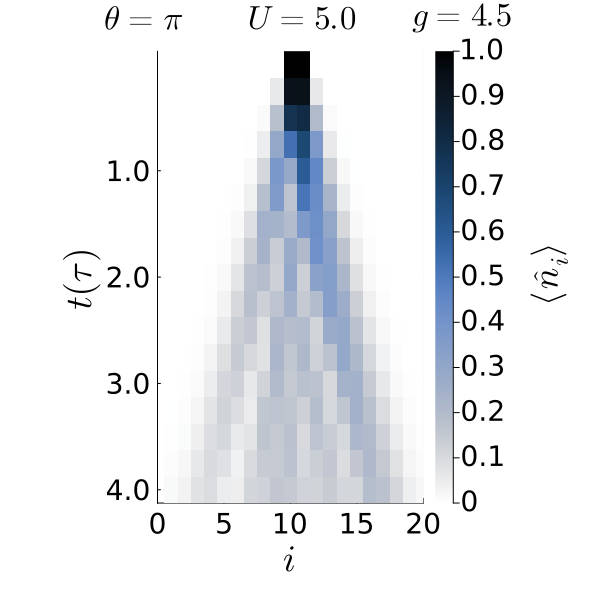

In [90]:
#Prueba para valores unicos 
quantum_walks(3.14159/2, +5.0 , +4.5)

In [245]:
U_values = [-5.0, 0.0 , 5.0] #0:0.1:10 
for Uva in U_values 
        quantum_walks(0.0, Uva, 0.0)
        savefig("qwalks-Uva-" * string(round(Uva, digits=2)) * "-theta-pi-g-zero.png") 
end

In [56]:
# savefig("QWalk-theta-zero-U-zero-style-1.png")

In [4]:
theo_result = zeros(length(t), M) 
#Define J runneling amplitude
for (i,j) in enumerate(t) 
    site = -Int(floor(M/2))
    for k in 1:M 
        theo_result[i, k] = (besselj(site, -2*1*j))^2
        site += 1
    end
end

LoadError: UndefVarError: `t` not defined

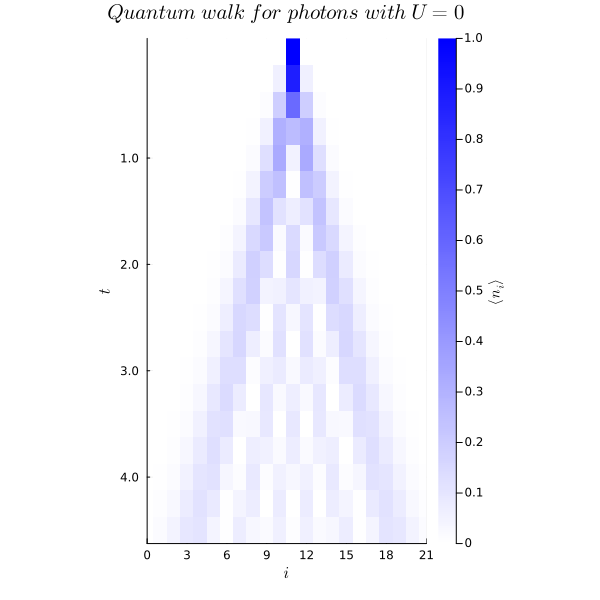

In [19]:
Tperiod = tfin
    y_full_ticks = 0:0.25:Tperiod  # Rango de la cuadricula (0 a tfin con pasos de 0.25)
    y_labels = vec(range(1, Tperiod + 1))     # Las etiquetas que quiero mostrar especificamente 
    y_label_indices = findall(x -> x in y_labels, y_full_ticks)  # Indices
heatmap(theo_result, color = cgrad([:white , :blue]), xlabel=L"i", ylabel=L"t", colorbar_title=L"\langle n_i \rangle",   yflip = true,  aspect_ratio=2, size=(600, 600), 
            yticks=(y_label_indices, y_labels), xlimits=(0,M) ,
            title=L"Quantum~walk~for~photons~with~U = 0") 

In [16]:
#theta_values = collect(LinRange(0, π, 32))  
theta_values =  collect(LinRange(0, π, 3)) 
U_values = 1.0 #0:0.1:10 
g_values = -5.0:1.0:5.0 # 5.1:0.1:6 #Sea g>U/2
for angle in theta_values 
    for Uva in U_values 
        for gva in g_values
            quantum_walks(angle, Uva, gva)
            savefig("qwalks-Uva-" * string(round(Uva, digits=2)) * "-theta-" * string(round(angle, digits=4)) * "-g-" * string(round(gva, digits=2)) * ".png") 
        end
    end 
end

## Probabilidad de pasar del estado $| \dots 0 1 1 0  \dots \rangle \rightarrow | \dots 0 0 1 1 \dots \rangle$ 

In [101]:
function next_right_state()
    vector = zeros(D)
    counter_position = 1;
    for i in v 
        if(i[Int(M/2 + 1)]==1 && i[Int(M/2 + 2)]==1) 
            vector[counter_position] = 1
            return vector
        end 
        counter_position+=1
    end  
    return "Deberia checar los sitios pares"
end

next_right_state (generic function with 1 method)

In [122]:
function prob_state_next_right(Uva::Float64, gva::Float64)#,  g::Float64=0.0, J::Float64=1.0)
    t_values = collect(LinRange(-π, π, 20)) 
    PR = Vector{Float64}() 
    r_state = next_right_state()
    for p in t_values
        Ht = H_theta(p, Uva, gva)
        H_spa = sparse(-1im*Ht)
        # tiempo de evolución dado por τ, fijo en 0.7 tau
        ψ₁ = expv(0.7, H_spa, ψ₀; m=125) 
        push!(PR, abs( ((r_state)' * ψ₁)^2) ) 
    end
    # return Γ   
    # plot(t_values/pi, PR, #color = cgrad([:white , :blue]) #:turbo #
    #     xlabel=L"\theta", ylabel=L"P", size=(600, 600), label=L"P_{R}",
    #       title=L"Probability~right~state~for~U = %$Uva ~g = %$gva", color=:green, lw= 2.0,
    #        # fuentes
    #        guidefontsize = 17,    # Títulos de ejes (i, t) 
    #        tickfontsize = 16) 
    #        #titlefontsize = 15)     # Título# clims=(0, 0.1))  
    plot!(t_values/pi, PR, 
    xlabel = L"\theta(\pi)", 
    ylabel = L"P", 
    size = (600, 600), 
    label = L"P_{R}, U = %$Uva ",
    # title = L"Probability~right~state~for~U = %$Uva ~g = %$gva", 
    color = :red, 
    lw = 2.0,
    guidefontsize = 17,    # Títulos de ejes
    tickfontsize = 16,     # Tamaño de los números en los ejes
    framestyle = :box,     # Añade los bordes superior y derecho
    widen = false ,         # Elimina el espacio extra para que empiece desde el borde 
    ylims=(0,0.25)
)
end

prob_state_next_right (generic function with 1 method)

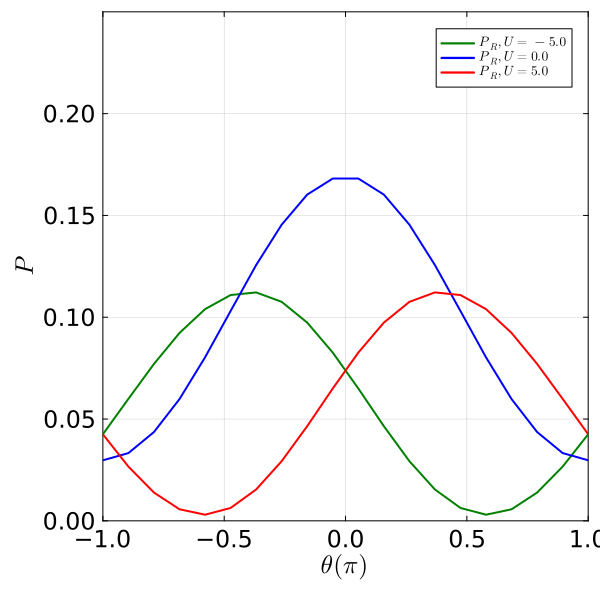

In [123]:
prob_state_next_right(5.0,0.0)

In [124]:
savefig("QWalk-Example-Prob-theta-U-probability-right-step.png")

"C:\\Users\\ronal\\Documents\\QWalks Papers\\QWalk-Example-Prob-theta-U-probability-right-step.png"

## Correlador posición

In [273]:
function density_density_correlator(θ::Float64, Uva::Float64, gva::Float64)#,  g::Float64=0.0, J::Float64=1.0)
    Ht = H_theta(θ::Float64, Uva, gva)
    H_spa = sparse(-1im*Ht)
    # tiempo de evolución dado por τ, fijo en 2.4 tau
    ψ₁ = expv(2.5, H_spa, ψ₀; m=125) 
    Γ = zeros(M,M)
        for i in 1:M
            for j in 1:M
                Γ[i, j] = real((ψ₁)' * matrixofcreacreationannann(i,j) * ψ₁)
            end
        end  
    # return Γ   
    heatmap(Γ/maximum(Γ), color =  cgrad(:oslo, rev=true)#cgrad([:white , :blue]) #:turbo #
        , xlabel=L"sitio~i", ylabel=L"sitio~j",  aspect_ratio=1, size=(600, 600), 
          # title=L"DDC~for~U = %$Uva ~ \theta = %$θ ~g = %$gva", 
           # fuentes
           guidefontsize = 23,    # Títulos de ejes (i, t) 
           colorbar_titlefontsize = 17, #Tamaño de la barra de calor
           tickfontsize = 19, 
        colorbar = false, right_margin = 2mm, top_margin = 8.5mm) 
     annotate!(5, 21, text(L"\theta= \pi", 23, :black)) 
    annotate!(15, 21, text(L"U= %$Uva", 23, :black))
           #titlefontsize = 15)     # Título# clims=(0, 0.1)) 
end

density_density_correlator (generic function with 1 method)

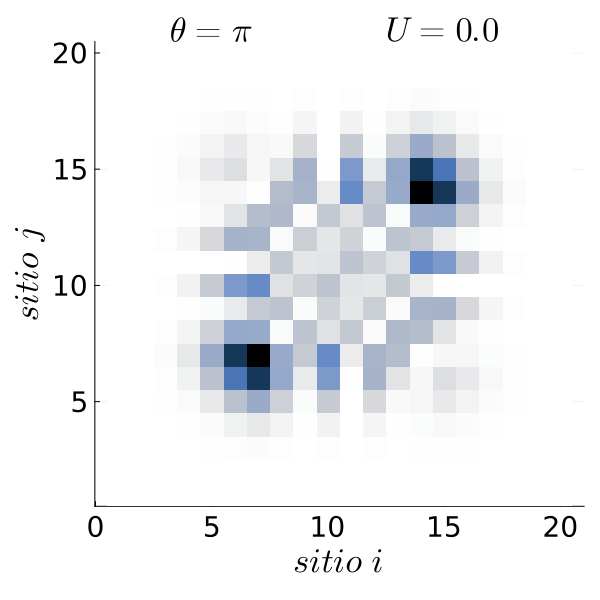

In [274]:
density_density_correlator(0.0,0.0,0.0)

In [275]:
theta_values = 3.14159
U_values = [-5.0, 0.0, 5.0] #0:0.1:10 
for angle in theta_values 
    for Uva in U_values 
            density_density_correlator(angle, Uva, 0.0)
            savefig("DDC1-Uva-" * string(round(Uva, digits=1)) * "-theta-" * string(round(angle, digits=3)) * "-g-zero.png")
    end 
end

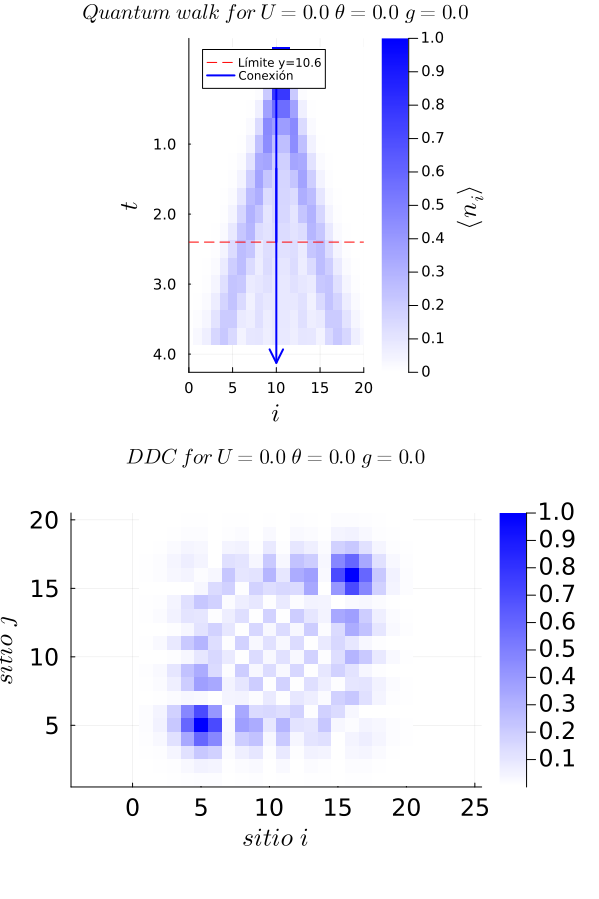

In [40]:

# 1. Definir la posición de la línea horizontal
y_pos = 2.4 / 0.25 + 1.0  # Resultado: 5.8

# 2. Generar las gráficas base
p1 = quantum_walks(0.0, 0.0, 0.0)
p2 = density_density_correlator(0.0, 0.0, 0.0)

# 3. Añadir la línea horizontal a la primera gráfica
hline!(p1, [y_pos], color=:red, linestyle=:dash, label="Límite y=$y_pos")

# 4. Configurar la segunda gráfica para que sea cuadrada
# aspect_ratio = :equal hace que las unidades de X e Y midan lo mismo físicamente
plot!(p2, aspect_ratio=1,  size=(600, 600))

# 5. Crear el layout
# Usamos un margen inferior en p1 y superior en p2 para que la flecha se vea mejor
l = @layout [a; b]
p_final = plot(p1, p2, layout=l, size=(600, 900), link=:x)

# 6. Dibujar la flecha que "sale" de la primera hacia la segunda
# Como no se puede cruzar fácilmente el borde de un subplot con una sola línea, 
# dibujamos una flecha en la parte inferior de p1 que apunte hacia abajo.
x_flecha = 10 # Punto en X donde quieres que nazca la conexión
plot!(p_final[1], [x_flecha, x_flecha], [y_pos, -0.5], # Ajusta el -0.5 según tus ejes
      arrow=true, 
      color=:blue, 
      lw=2, 
      label="Conexión")

display(p_final)

In [ ]:
theta_values = collect(LinRange(0, π, 32)) 
U_values = 0.0 #0:0.1:10 
g_values = 0.0 # 5.1:0.1:6 #Sea g>U/2
for angle in theta_values 
    for Uva in U_values 
        for gva in g_values
            density_density_correlator(angle, Uva, gva)
            savefig("DDC1-Uva-" * string(round(Uva, digits=1)) * "-theta-" * string(round(angle, digits=3)) * "-g-" * string(round(gva, digits=2)) * ".png")
        end
    end 
end

## Correlador cuasi-momenta

In [48]:
#hacemos el espacio de k para 20 valores 
dx = 1.0       # Distance between sites (lattice constant)
# fftfreq(M, sampling_rate)
# Note: sampling_rate = 1/dx
k_values = 2π * fftfreq(M, 1/dx) 
k_centered = fftshift(k_values)

-3.141592653589793:0.3141592653589793:2.827433388230814

In [49]:
collect(range(-pi, pi , 20))

20-element Vector{Float64}:
 -3.141592653589793
 -2.8108986900540254
 -2.4802047265182576
 -2.14951076298249
 -1.8188167994467224
 -1.4881228359109546
 -1.1574288723751869
 -0.8267349088394192
 -0.49604094530365156
 -0.16534698176788384
  0.16534698176788384
  0.49604094530365156
  0.8267349088394192
  1.1574288723751869
  1.4881228359109546
  1.8188167994467224
  2.14951076298249
  2.4802047265182576
  2.8108986900540254
  3.141592653589793

In [54]:
function density_density_correlator_momentum(θ::Float64, Uva::Float64, gva::Float64)#,  g::Float64=0.0, J::Float64=1.0)
    Ht = H_theta(θ::Float64, Uva, gva)
    H_spa = sparse(-1im*Ht)
    ψ₁ = expv(4.0, H_spa, ψ₀; m=125) 
    Γ = zeros(M,M)
        for α in 1:M
            for β in 1:M  
                vals = 0
                for i in 1:M, d in 1:M, k in 1:M, g in 1:M
                    vals += exp((1im*2*π/M)*(α*(i-g)+β*(d-k))) *  real((ψ₁)' * matrix_of_crea_crea_ann_ann(i, d, k, g) * ψ₁)
                end
                Γ[α, β] = (1/M^2) * real(vals)
            end
        end  
    #return Γ   
    heatmap(Γ/maximum(Γ), color = :turbo #cgrad([:white , :blue])
        , xlabel=L"\alpha~site", ylabel=L"\beta~site",  aspect_ratio=1, size=(600, 600), 
          title=L"DDCM~for~U = %$Uva ~ \theta = %$θ ~g = %$gva")# clims=(0, 0.1)) 
end

density_density_correlator_momentum (generic function with 1 method)

2244.515994 seconds (15.36 G allocations: 21.231 TiB, 3.16% gc time, 0.00% compilation time)


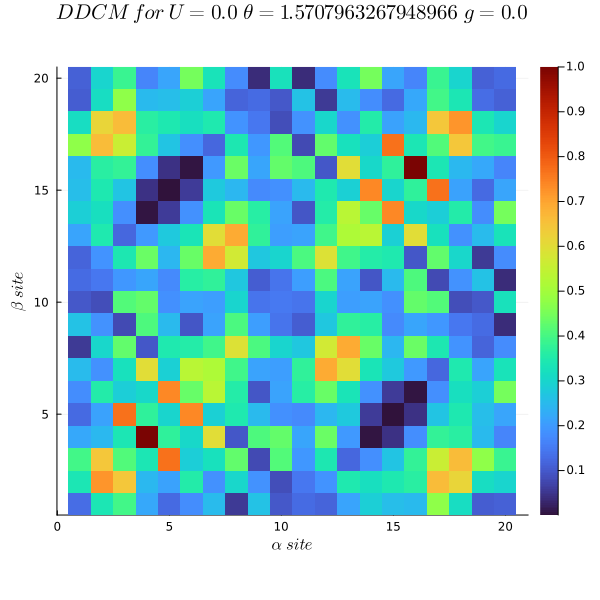

In [55]:
@time density_density_correlator_momentum(pi/2,0.0,0.0)

In [115]:
function density_density_correlator_momentum(θ::Float64, Uva::Float64, gva::Float64)
    Ht = H_theta(θ, Uva, gva)
    H_spa = sparse(-1im * Ht)
    
    # Funcion de onda a un tiempo t = 4.0
    ψ₁ = expv(4.0, H_spa, ψ₀; m=125)
    # Inicializamos la matriz
    Γ_complex = zeros(ComplexF64, M, M)
    # Primero calculamoos los valores de los productos esperados con indices i, d, k, g. 
    for i in 1:M, d in 1:M, k in 1:M, g in 1:M
        # Valores esperados
        term = real((ψ₁)' * matrix_of_crea_crea_ann_ann(i, d, k, g) * ψ₁)
        if term == 0
            continue
        end
        # Ahora desarrollamos para los valores α y β, notemos que hay una simetria para la parte triangular superior para esta  
        # matriz anti diagonal 
        site_a = -Int(floor(M/2)) 
        for α in 1:M 
            site_b = -Int(floor(M/2)) 
            for β in 1:M#(M - α + 1) # Donde la por la simetria realizamos calculos con la restricción α + β <= M + 1 y reflejamos.
                phase = exp((1im * 2 * π / M) * (site_a * (i - g) + site_b * (d - k))) 
                Γ_complex[α, β] += phase * term  #* site_b* site_a 
                site_b += 1
            end 
            site_a += 1
        end
    end

    Γ = zeros(Float64, M, M)

    for α in 1:M
        for β in 1:M#(M - α + 1)
            # Tomanfo la parte real
            val = (1 / M^2) * real(Γ_complex[α, β]) # * (1/site_a) 
            
            # Valor del correlador en para un α, β
            Γ[α, β] = val 
            
            # if α + β != M + 1
            #     # Simetria anti-diagonal, α_simetrico = M - β + 1 , β_simetrico = M - α + 1
            #     Γ[M - β + 1, M - α + 1] = val
            # end 
        end 
    end
    return heatmap(Γ / maximum(Γ), color = :turbo, #cgrad([:white , :blue]) , #:turbo,
        xlabel=L"\alpha~site", ylabel=L"\beta~site", aspect_ratio=1, size=(600, 600),
        title=L"DDCM~for~U = %$Uva ~ \theta = %$θ ~g = %$gva")
end

density_density_correlator_momentum (generic function with 1 method)

In [58]:
function density_density_correlator_momentum(θ::Float64, Uva::Float64, gva::Float64)    
    Ht = H_theta(θ, Uva, gva)
    H_spa = sparse(-1im * Ht)
    ψ₁ = expv(4.0, H_spa, ψ₀; m=125) 
    
    # Definimos el espacio de momentum -π a π usando FFTW 
     k_values = 2π * fftfreq(M, 1/dx) 
     k_centered = fftshift(k_values) 
     k_vec = k_centered

    expect_vals = zeros(ComplexF64, M, M, M, M)
    for i in 1:M, d in 1:M, k in 1:M, g in 1:M
        # dot(ψ₁, A * ψ₁) 
        expect_vals[i, d, k, g] = dot(ψ₁, matrix_of_crea_crea_ann_ann(i, d, k, g) * ψ₁)
    end
    
    Γ = zeros(Float64, M, M)
    
    # con el espacio de momento definido evaluamos y guardamos
    for (idx_α, p_α) in enumerate(k_vec)
        for (idx_β, p_β) in enumerate(k_vec)  
            vals = 0.0 + 0.0im # inicializo 
            
            for i in 1:M, d in 1:M, k in 1:M, g in 1:M
                # sea la fase de los 4 operadores p_α*(l-l') + p_β*(z-z')
                phase = exp(1im * (p_α*(i-g) + p_β*(d-k)))
                
                # fase obtenida y valor esperado
                vals += phase * expect_vals[i, d, k, g]
            end
             Γ[idx_α, idx_β] = (1/M^2) * real(vals)
        end
    end  
    
    # Graf
    heatmap(k_vec, k_vec, Γ ./ maximum(abs.(Γ)), 
        color = cgrad(:CMRmap, rev=true), 
        xlabel = L"k_\alpha", 
        ylabel = L"k_\beta",  
        aspect_ratio = 1, top_margin = 7mm,
        size = (600, 600),  colorbar= false) 
    annotate!(1, 3.25, text(L"\theta= \pi/2", 15, :black)) 
    annotate!(2.3, 3.25, text(L"U= %$Uva", 15, :black))
        #title = L"DDCM~for~U = %$Uva ~ \theta = %$θ ~g = %$gva" 
end

density_density_correlator_momentum (generic function with 1 method)

In [316]:
function density_density_correlator_momentum(θ::Float64, Uva::Float64, gva::Float64)    
    Ht = H_theta(θ, Uva, gva)
    H_spa = sparse(-1im * Ht)
    ψ₁ = expv(2.4, H_spa, ψ₀; m=125) 
    
    # Define a symmetric momentum space from -π to π perfectly
    # By using M+1, you maintain the same step size but include the +π edge
    k_vec = range(-π, π, length=M+1)
    N_k = length(k_vec)

    expect_vals = zeros(ComplexF64, M, M, M, M)
    for i in 1:M, d in 1:M, k in 1:M, g in 1:M
        # dot(ψ₁, A * ψ₁) 
        expect_vals[i, d, k, g] = dot(ψ₁, matrix_of_crea_crea_ann_ann(i, d, k, g) * ψ₁)
    end
    
    # Initialize Γ with the new momentum grid size (M+1 x M+1)
    Γ = zeros(Float64, N_k, N_k)
    
    # Con el espacio de momento definido evaluamos y guardamos
    for (idx_α, p_α) in enumerate(k_vec)
        for (idx_β, p_β) in enumerate(k_vec)  
            vals = 0.0 + 0.0im # inicializo 
            
            # Note: Spatial loops still go up to M!
            for i in 1:M, d in 1:M, k in 1:M, g in 1:M
                # sea la fase de los 4 operadores p_α*(l-l') + p_β*(z-z')
                phase = exp(1im * (p_α*(i-g) + p_β*(d-k)))
                
                # fase obtenida y valor esperado
                vals += phase * expect_vals[i, d, k, g]
            end
             Γ[idx_α, idx_β] = (1/M^2) * real(vals)
        end
    end  

    ypositions = [-π/2, 0, π/2, π]
    ylabels = [ L"-π/2", L"0", L"π/2", L"π"]
    # Graf
    heatmap(k_vec, k_vec, Γ ./ maximum(abs.(Γ)), 
        color = cgrad(:oslo, rev=true), 
        xlabel = L"k_\alpha", 
        ylabel = L"k_\beta",  
        aspect_ratio = 1, top_margin = 8mm, right_margin = 6mm, down_margin = 8mm, 
        guidefontsize = 25,    # Títulos de ejes (i, t) 
        colorbar_titlefontsize = 24, #Tamaño de la barra de calor
        tickfontsize = 23,
        size = (600, 600),  colorbar= false, 
        xticks = (ypositions, ylabels), 
        yticks = (ypositions, ylabels) )  
    annotate!(-3.74159, -3.84159, text(L"-\pi", 23, :black))
    annotate!(-2.0, 3.52, text(L"\theta= \pi", 23, :black)) 
    annotate!(2.0, 3.52, text(L"U= %$Uva", 23, :black))
end

density_density_correlator_momentum (generic function with 1 method)

 32.019662 seconds (821.70 M allocations: 75.618 GiB, 4.11% gc time)


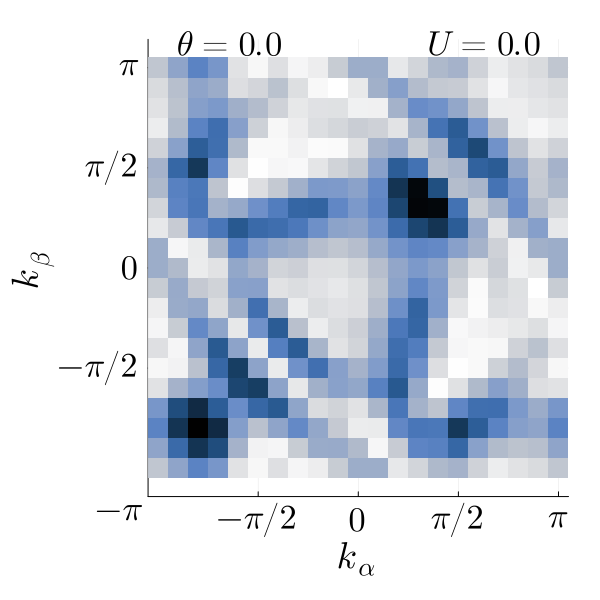

In [312]:
@time density_density_correlator_momentum(3.14159/2,0.0,0.0)

 28.704063 seconds (821.70 M allocations: 75.618 GiB, 4.60% gc time)


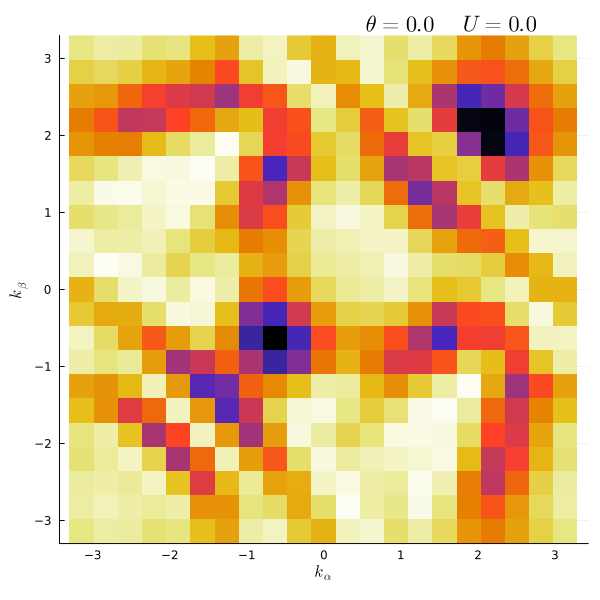

In [53]:
@time density_density_correlator_momentum(-3.14159/2,0.0,0.0)

In [318]:
theta_values = 3.14159
U_values = [-5.0, 0.0, 5.0] #0:0.1:10 
for angle in theta_values 
    for Uva in U_values 
            density_density_correlator_momentum(angle, Uva, 0.0)
            savefig("QMS-DDC1-Uva-" * string(round(Uva, digits=1)) * "-theta-" * string(round(angle, digits=3)) * "-g-zero.png")
    end 
end

In [ ]:
function density_density_correlator_momentum(θ::Float64, Uva::Float64, gva::Float64)    
    Ht = H_theta(θ, Uva, gva)
    H_spa = sparse(-1im * Ht)
    ψ₁ = expv(4.0, H_spa, ψ₀; m=125) 
    
    # Definimos el espacio de momentum -π a π en M partes
     k_values = 2π * fftfreq(M, 1/dx) 
     k_centered = fftshift(k_values) 
     p_vec = k_centered
    
    expect_vals = zeros(ComplexF64, M, M, M, M)
    for i in 1:M, d in 1:M, k in 1:M, g in 1:M
        # dot(ψ₁, A * ψ₁) 
        expect_vals[i, d, k, g] = dot(ψ₁, matrix_of_crea_crea_ann_ann(i, d, k, g) * ψ₁)
    end
    
    Γ = zeros(Float64, M, M)
    
    # con el espacio de momento definido evaluamos y guardamos
    for (idx_α, p_α) in enumerate(p_vec)
        for (idx_β, p_β) in enumerate(p_vec)  
            vals = 0.0 + 0.0im # inicializo 
            
            for i in 1:M, d in 1:M, k in 1:M, g in 1:M
                # sea la fase de los 4 operadores p_α*(l-l') + p_β*(z-z')
                phase = exp(1im * (p_α*(i-g) + p_β*(d-k)))
                
                # fase obtenida y valor esperado
                vals += phase * expect_vals[i, d, k, g]
            end
             Γ[idx_α, idx_β] = (1/M^2) * real(vals)
        end
    end  
    
    # Graf
    heatmap(p_vec, p_vec, Γ ./ maximum(abs.(Γ)), 
        color = :turbo, 
        xlabel = L"p_\alpha", 
        ylabel = L"p_\beta",  
        aspect_ratio = 1, 
        size = (600, 600), 
        title = L"DDCM~for~U = %$Uva ~ \theta = %$θ ~g = %$gva"
    ) 
end

 72.703878 seconds (500.88 M allocations: 68.001 GiB, 15.59% gc time, 0.04% compilation time)


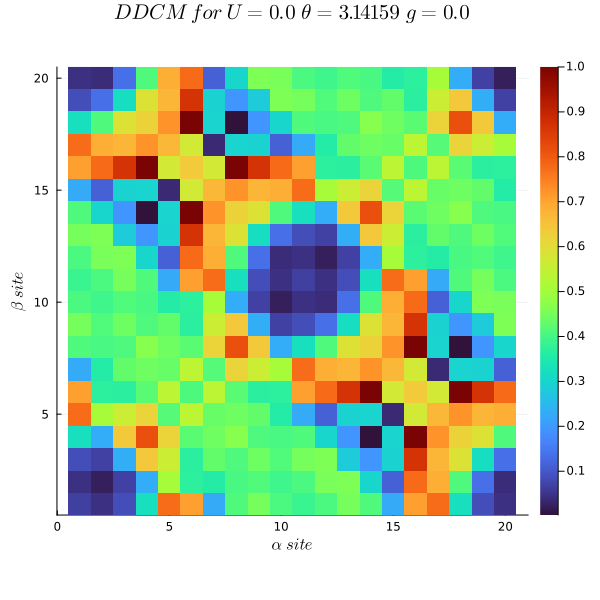

In [116]:
@time density_density_correlator_momentum(3.14159,0.0,0.0)

In [ ]:
theta_values = collect(LinRange(0, π, 32)) 
U_values = 0.0 #0:0.1:10 
g_values = 0.0 # 5.1:0.1:6 #Sea g>U/2
for angle in theta_values 
    for Uva in U_values 
        for gva in g_values
            density_density_correlator_momentum(angle, Uva, gva)
            savefig("QM-DDC1-Uva-" * string(round(Uva, digits=1)) * "-theta-" * string(round(angle, digits=3)) * "-g-" * string(round(gva, digits=2)) * ".png")
        end
    end 
end

## Factor de estructura

In [344]:
qparts = 100
q_values = collect(LinRange(0, π, qparts)) 
#Valores del tiempo
t_values = 0:0.01:tfin 
function static_struct_factor(θ::Float64, Uva::Float64, gva::Float64)#,  g::Float64=0.0, J::Float64=1.0)
    #prep of states
    Ht = H_theta(θ::Float64, Uva, gva)
    H_spa = sparse(-1im*Ht)
    #t = 0:0.001:tfin
    # Precompute the time evolution operator for each τ
    ψ_states = [expv(τ, H_spa, ψ₀; m=100) for τ in t_values]; 
    #results = zeros(length(t_values), length(q_values));
    results = zeros(length(ψ_states), length(q_values))
    diags = [diag(M) for M in Mocup]
    D = transpose(reduce(hcat, diags))   
    for (i, ψ_vec) in enumerate(ψ_states)
        # Calcula probabilidades |ψ_vec|^2
        prob = abs2.(ψ_vec)    
        # Hace E_r = ⟨M_r⟩ para todo r (M-elemento vectyor)
        E_r = D * prob  # Multiplicacion Matriz Vector(M x n) * (n) → (M)
        for (q_idx, q) in enumerate(q_values)
            # Hacemos exp(i*q*r) para todo r
            exp_iq_r = exp.(1im * q .* (1:M))
            
            # Termino-1: sum_i prob[i] * |sum_r D[r,i] * exp(i*q*r)|^2
            sum_terms = D' * exp_iq_r  # (n x M) * (M) → (n)
            term1 = dot(prob, abs2.(sum_terms))
            
            # Termino-2: |sum_r E_r * exp(i*q*r)|^2
            sum_Er_exp = dot(E_r, exp_iq_r)
            term2 = abs2(sum_Er_exp)
            
            # Guarda los resultados de real(termino-1 - termino-2)
            results[i, q_idx] = real(term1 - term2)
        end
    end    
     heatmap(t_values, q_values/pi, transpose(results)/maximum(results), xlabel=L"t(\tau)", ylabel=L"\tilde{q}", 
        colorbar_title= "\n " * L"\langle S(\bar{q}) \rangle", 
        guidefontsize = 25,    # Títulos de ejes (i, t) 
        colorbar_titlefontsize = 24, #Tamaño de la barra de calor
        tickfontsize = 23, size = (1100,800), right_margin = 18mm, left_margin = 5mm, down_margin = 20mm,
    title=L"Factor~de~estructura~estático~con~U = %$Uva ~ \theta = %$θ ~g = %$gva", yflip = false,color =cgrad(:tempo, rev=true))
end

static_struct_factor (generic function with 1 method)

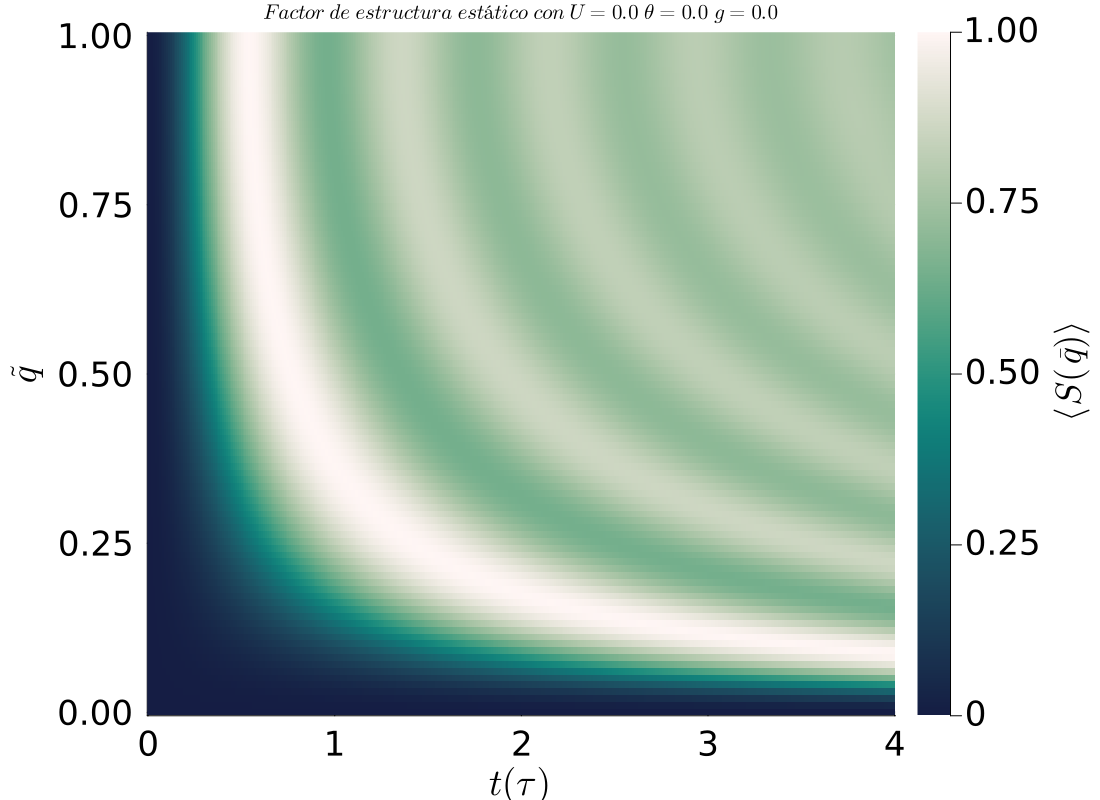

In [345]:
static_struct_factor(0.0, 0.0,0.0)

In [346]:
#theta_values = collect(LinRange(0, π, 32))  
theta_values =  collect(LinRange(0, π, 3)) 
U_values = [-1.0, 0.0, 1.0] #0:0.1:10 
g_values = 0.0#-5.0:5.0:5.0 # 5.1:0.1:6 #Sea g>U/2
for angle in theta_values 
    for Uva in U_values 
        for gva in g_values
            static_struct_factor(angle, Uva, gva)
            savefig("SSF-Uva-" * string(round(Uva, digits=1)) * "-theta-" * string(round(angle, digits=3)) * "-g-" * string(round(gva, digits=2)) * ".png")
        end
    end 
end